# Explore here

In [ ]:
# Your code here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report


ds = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv", sep =",")

ds


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,...,Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,...,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,...,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.362847,2244,9.018930,1048,4.212049,12209,49.069571,12042,48.398376,164,0.659137,113,0.454162,46,0.184880,307,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,...,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,6150,23.5,Barbour,Alabama,1,5,19689,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,13.562500,3115,13.906250,2545,11.361607,1723,7.691964,785,3.504464,17211,76.834821,4770,21.294643,98,0.437500,53,0.236607,26,0.116071,242,1.080357,22400,-155,2151,11.1,11.4,-0.3,0.4,-7.0,-6.6,...,6.9,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,4773,21.1,Bibb,Alabama,1,7,17813,51.6,49.6,53.4,9190,38.7,37.4,40.2,6894,8.6,7.9,9.3,1533,10.0,8.8,11.3,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,12.921853,7844,13.561549,6965,12.041840,4931,8.525242,2335,4.036999,55456,95.878285,950,1.642462,378,0.653527,185,0.319848,70,0.121024,801,1.384855,57840,13,489,11.8,11.4,0.3,0.1,-0.2,0.0,...,6.9,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,13600,23.6,Blount,Alabama,1,

In [50]:
for col in ds.columns:
    print(col)

fips
TOT_POP
0-9
0-9 y/o % of total pop
19-Oct
10-19 y/o % of total pop
20-29
20-29 y/o % of total pop
30-39
30-39 y/o % of total pop
40-49
40-49 y/o % of total pop
50-59
50-59 y/o % of total pop
60-69
60-69 y/o % of total pop
70-79
70-79 y/o % of total pop
80+
80+ y/o % of total pop
White-alone pop
% White-alone
Black-alone pop
% Black-alone
Native American/American Indian-alone pop
% NA/AI-alone
Asian-alone pop
% Asian-alone
Hawaiian/Pacific Islander-alone pop
% Hawaiian/PI-alone
Two or more races pop
% Two or more races
POP_ESTIMATE_2018
N_POP_CHG_2018
GQ_ESTIMATES_2018
R_birth_2018
R_death_2018
R_NATURAL_INC_2018
R_INTERNATIONAL_MIG_2018
R_DOMESTIC_MIG_2018
R_NET_MIG_2018
Less than a high school diploma 2014-18
High school diploma only 2014-18
Some college or associate's degree 2014-18
Bachelor's degree or higher 2014-18
Percent of adults with less than a high school diploma 2014-18
Percent of adults with a high school diploma only 2014-18
Percent of adults completing some college 

In [51]:
columnas_categoricas = ds.select_dtypes(include= ["object"]).columns

columnas_categoricas

C:\Users\trimb\AppData\Local\Temp\ipykernel_111760\4172201675.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = ds.select_dtypes(include= ["object"]).columns


Index(['COUNTY_NAME', 'STATE_NAME'], dtype='str')

In [52]:
ds['STATE_NAME'].value_counts().sum()

np.int64(3140)

In [53]:
# Busco valores nulos

ds.info(verbose= True)

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 108 columns):
 #    Column                                                                         Dtype  
---   ------                                                                         -----  
 0    fips                                                                           int64  
 1    TOT_POP                                                                        int64  
 2    0-9                                                                            int64  
 3    0-9 y/o % of total pop                                                         float64
 4    19-Oct                                                                         int64  
 5    10-19 y/o % of total pop                                                       float64
 6    20-29                                                                          int64  
 7    20-29 y/o % of total pop                                    

In [54]:
ds.drop(["0-9", "19-Oct", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+", "White-alone pop", "Black-alone pop", "Native American/American Indian-alone pop", "Asian-alone pop", "Hawaiian/Pacific Islander-alone pop", "Two or more races pop", "POP_ESTIMATE_2018", "N_POP_CHG_2018", "R_birth_2018", "R_death_2018", "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "Less than a high school diploma 2014-18", "High school diploma only 2014-18", "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", "POVALL_2018", "PCTPOV017_2018", "PCTPOV517_2018", "CI90LBINC_2018", "CI90UBINC_2018", "Employed_2018", "Unemployed_2018", "Median_Household_Income_2018", "anycondition_Lower 95% CI", "anycondition_Upper 95% CI", "anycondition_number", "Obesity_Lower 95% CI", "Obesity_Upper 95% CI", "Obesity_number", "Heart disease_Lower 95% CI", "Heart disease_Upper 95% CI", "Heart disease_number", "COPD_Lower 95% CI", "COPD_Upper 95% CI", "COPD_number", "diabetes_Lower 95% CI", "diabetes_Upper 95% CI", "diabetes_number", "CKD_Lower 95% CI", "CKD_Upper 95% CI", "CKD_number", "Population Aged 60+", "Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)", "Active Primary Care Physicians per 100000 Population 2018 (AAMC)", "Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)", "Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)", "COUNTY_NAME"], axis = 1, inplace = True)

pd.set_option("display.max_columns", 83)

ds

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,GQ_ESTIMATES_2018,R_NATURAL_INC_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,MEDHHINC_2018,Civilian_labor_force_2018,Unemployment_rate_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,455,2.2,0.6,11.3,32.6,28.4,27.7,13.8,59338,25957,3.6,119.0,217.1,7.6,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Alabama,1,1,42438,47.6,35.8,7.9,8.6,12.9,3.1,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,2190,0.1,24.8,9.7,27.6,31.3,31.3,9.8,57588,93849,3.6,115.5,217.1,7.6,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Alabama,1,3,170912,40.2,29.7,7.8,8.6,12.0,3.2,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,2820,-2.5,-8.6,27.0,35.7,25.1,12.2,30.9,34382,8373,5.2,68.9,217.1,7.6,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Alabama,1,5,19689,57.5,40.7,11.0,12.1,19.7,4.5,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,2151,-0.3,-6.6,16.8,47.3,24.4,11.5,21.8,46064,8661,4.0,92.3,217.1,7.6,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,21.1,Alabama,1,7,17813,51.6,38.7,8.6,10.0,14.1,3.3,2
4,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,1.642462,0.653527,0.319848,0.121024,1.384855,489,0.3,0.0,19.8,34.0,33.5,12.6,13.2,50412,25006,3.5,101.1,217.1,7.6,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,23.6,Alabama,1,9,44448,46.3,34.0,9.2,10.5,13.5,3.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,14.178532,14.694200,12.448027,15.277229,12.389956,12.220390,11.481731,5.105572,2.204362,93.835219,1.375113,1.544680,1.010429,0.157952,2.076607,660,5.6,-17.2,9.0,33.3,35.7,22.0,8.4,73315,21150,4.2,117.8,207.9,10.6,21.311749,11.997173,2.160982,9.836192,28.018244,40.537033,10,44527,15.8,Wyoming,56,37,31761,40.3,33.6,5.9,6.6,8.9,2.6,5
3136,56039,23081,10.328842,9.466661,12.854729,17.733200,14.830380,12.685759,12.456133,6.797799,2.846497,95.190850,0.758199,0.914172,1.412417,0.151640,1.572722,270,6.7,-14.5,5.6,13.2,23.8,57.4,6.3,99087,15340,3.0,159.2,207.9,10.6,11.425901,6.432063,1.158570,5.273493,15.021465,21.733183,6,22923,18.7,Wyoming,56,39,18842,24.3,19.4,5.2,4.9,7.2,2.4,5
3137,56041,20299,15.375142,

In [55]:
# Hago un label encoder para poder hacer el heatmap de correlacion. Creo una nueva variable ds_label_encoded para poder usarla solo para el heatmap de correlacion

columnas_categoricas = ds.select_dtypes(include= ["object"]).columns

ds_label_coded = ds.copy()

le = LabelEncoder()

ds_label_coded[columnas_categoricas] = ds_label_coded[columnas_categoricas].apply(le.fit_transform)

ds_label_coded

C:\Users\trimb\AppData\Local\Temp\ipykernel_111760\1556588730.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = ds.select_dtypes(include= ["object"]).columns


,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,GQ_ESTIMATES_2018,R_NATURAL_INC_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,MEDHHINC_2018,Civilian_labor_force_2018,Unemployment_rate_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,455,2.2,0.6,11.3,32.6,28.4,27.7,13.8,59338,25957,3.6,119.0,217.1,7.6,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,0,1,1,42438,47.6,35.8,7.9,8.6,12.9,3.1,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,2190,0.1,24.8,9.7,27.6,31.3,31.3,9.8,57588,93849,3.6,115.5,217.1,7.6,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,0,1,3,170912,40.2,29.7,7.8,8.6,12.0,3.2,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,2820,-2.5,-8.6,27.0,35.7,25.1,12.2,30.9,34382,8373,5.2,68.9,217.1,7.6,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,0,1,5,19689,57.5,40.7,11.0,12.1,19.7,4.5,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,2151,-0.3,-6.6,16.8,47.3,24.4,11.5,21.8,46064,8661,4.0,92.3,217.1,7.6,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,21.1,0,1,7,17813,51.6,38.7,8.6,10.0,14.1,3.3,2
4,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,1.642462,0.653527,0.319848,0.121024,1.384855,489,0.3,0.0,19.8,34.0,33.5,12.6,13.2,50412,25006,3.5,101.1,217.1,7.6,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,23.6,0,1,9,44448,46.3,34.0,9.2,10.5,13.5,3.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,14.178532,14.694200,12.448027,15.277229,12.389956,12.220390,11.481731,5.105572,2.204362,93.835219,1.375113,1.544680,1.010429,0.157952,2.076607,660,5.6,-17.2,9.0,33.3,35.7,22.0,8.4,73315,21150,4.2,117.8,207.9,10.6,21.311749,11.997173,2.160982,9.836192,28.018244,40.537033,10,44527,15.8,50,56,37,31761,40.3,33.6,5.9,6.6,8.9,2.6,5
3136,56039,23081,10.328842,9.466661,12.854729,17.733200,14.830380,12.685759,12.456133,6.797799,2.846497,95.190850,0.758199,0.914172,1.412417,0.151640,1.572722,270,6.7,-14.5,5.6,13.2,23.8,57.4,6.3,99087,15340,3.0,159.2,207.9,10.6,11.425901,6.432063,1.158570,5.273493,15.021465,21.733183,6,22923,18.7,50,56,39,18842,24.3,19.4,5.2,4.9,7.2,2.4,5
3137,56041,20299,15.375142,15.788955,10.606434,13.311001,11.773979,

In [58]:
x = ds_label_coded.drop(['diabetes_prevalence'], axis = 1)
y = ds_label_coded["diabetes_prevalence"]

In [59]:
selector = SelectKBest(score_func=f_regression, k=20)
X_new = selector.fit_transform(x, y)

print("Forma original:", x.shape)
print("Forma reducida:", X_new.shape)

Forma original: (3140, 50)
Forma reducida: (3140, 20)


In [62]:
# Obtengo una máscara True/False indicando qué columnas fueron seleccionadas
mask = selector.get_support()

# Extraemos los nombres de las columnas seleccionadas
selected_cols = np.array(ds_label_coded.columns.drop(['diabetes_prevalence']))[mask]

selected_cols

array(['30-39 y/o % of total pop', '70-79 y/o % of total pop',
       '% White-alone', '% Black-alone', '% Asian-alone',
       'R_NATURAL_INC_2018',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       "Percent of adults with a bachelor's degree or higher 2014-18",
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Unemployment_rate_2018',
       'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'anycondition_prevalence', 'Obesity_prevalence',
       'Heart disease_prevalence', 'COPD_prevalence', 'CKD_prevalence',
       'Urban_rural_code'], dtype=object)

In [72]:
ds_correlacion = ds_label_coded[selected_cols]

ds_correlacion["diabetes_prevalence"] = y

ds_correlacion

,30-39 y/o % of total pop,70-79 y/o % of total pop,% White-alone,% Black-alone,% Asian-alone,R_NATURAL_INC_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,MEDHHINC_2018,Unemployment_rate_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,CKD_prevalence,Urban_rural_code,diabetes_prevalence
0,12.749771,7.284042,76.725239,19.630942,1.224798,2.2,11.3,32.6,27.7,13.8,59338,3.6,119.0,217.1,47.6,35.8,7.9,8.6,3.1,3,12.9
1,11.564429,9.602701,87.285228,8.940382,1.150343,0.1,9.7,27.6,31.3,9.8,57588,3.6,115.5,217.1,40.2,29.7,7.8,8.6,3.2,4,12.0
2,12.865239,9.018930,49.069571,48.398376,0.454162,-2.5,27.0,35.7,12.2,30.9,34382,5.2,68.9,217.1,57.5,40.7,11.0,12.1,4.5,6,19.7
3,13.897321,7.691964,76.834821,21.294643,0.236607,-0.3,16.8,47.3,11.5,21.8,46064,4.0,92.3,217.1,51.6,38.7,8.6,10.0,3.3,2,14.1
4,11.901798,8.525242,95.878285,1.642462,0.319848,0.3,19.8,34.0,12.6,13.2,50412,3.5,101.1,217.1,46.3,34.0,9.2,10.5,3.4,2,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,15.277229,5.105572,93.835219,1.375113,1.010429,5.6,9.0,33.3,22.0,8.4,73315,4.2,117.8,207.9,40.3,33.6,5.9,6.6,2.6,5,8.9
3136,17.733200,6.797799,95.190850,0.758199,1.412417,6.7,5.6,13.2,57.4,6.3,99087,3.0,159.2,207.9,24.3,19.4,5.2,4.9,2.4,5,7.2
3137,13.311001,6.074191,95.354451,0.827627,0.472930,6.3,7.2,40.1,15.4,10.0,63401,4.4,101.8,207.9,42.2,34.2,7.2,8.0,3.0,5,10.4
3138,11.452124,9.397590,94.483196,0.507292,0.824350,-1.4,10.4,30.3,21.5,11.9,55190,4.2,88.6,207.9,37.5,28.4,8.2,8.3,3.4,6,11.3


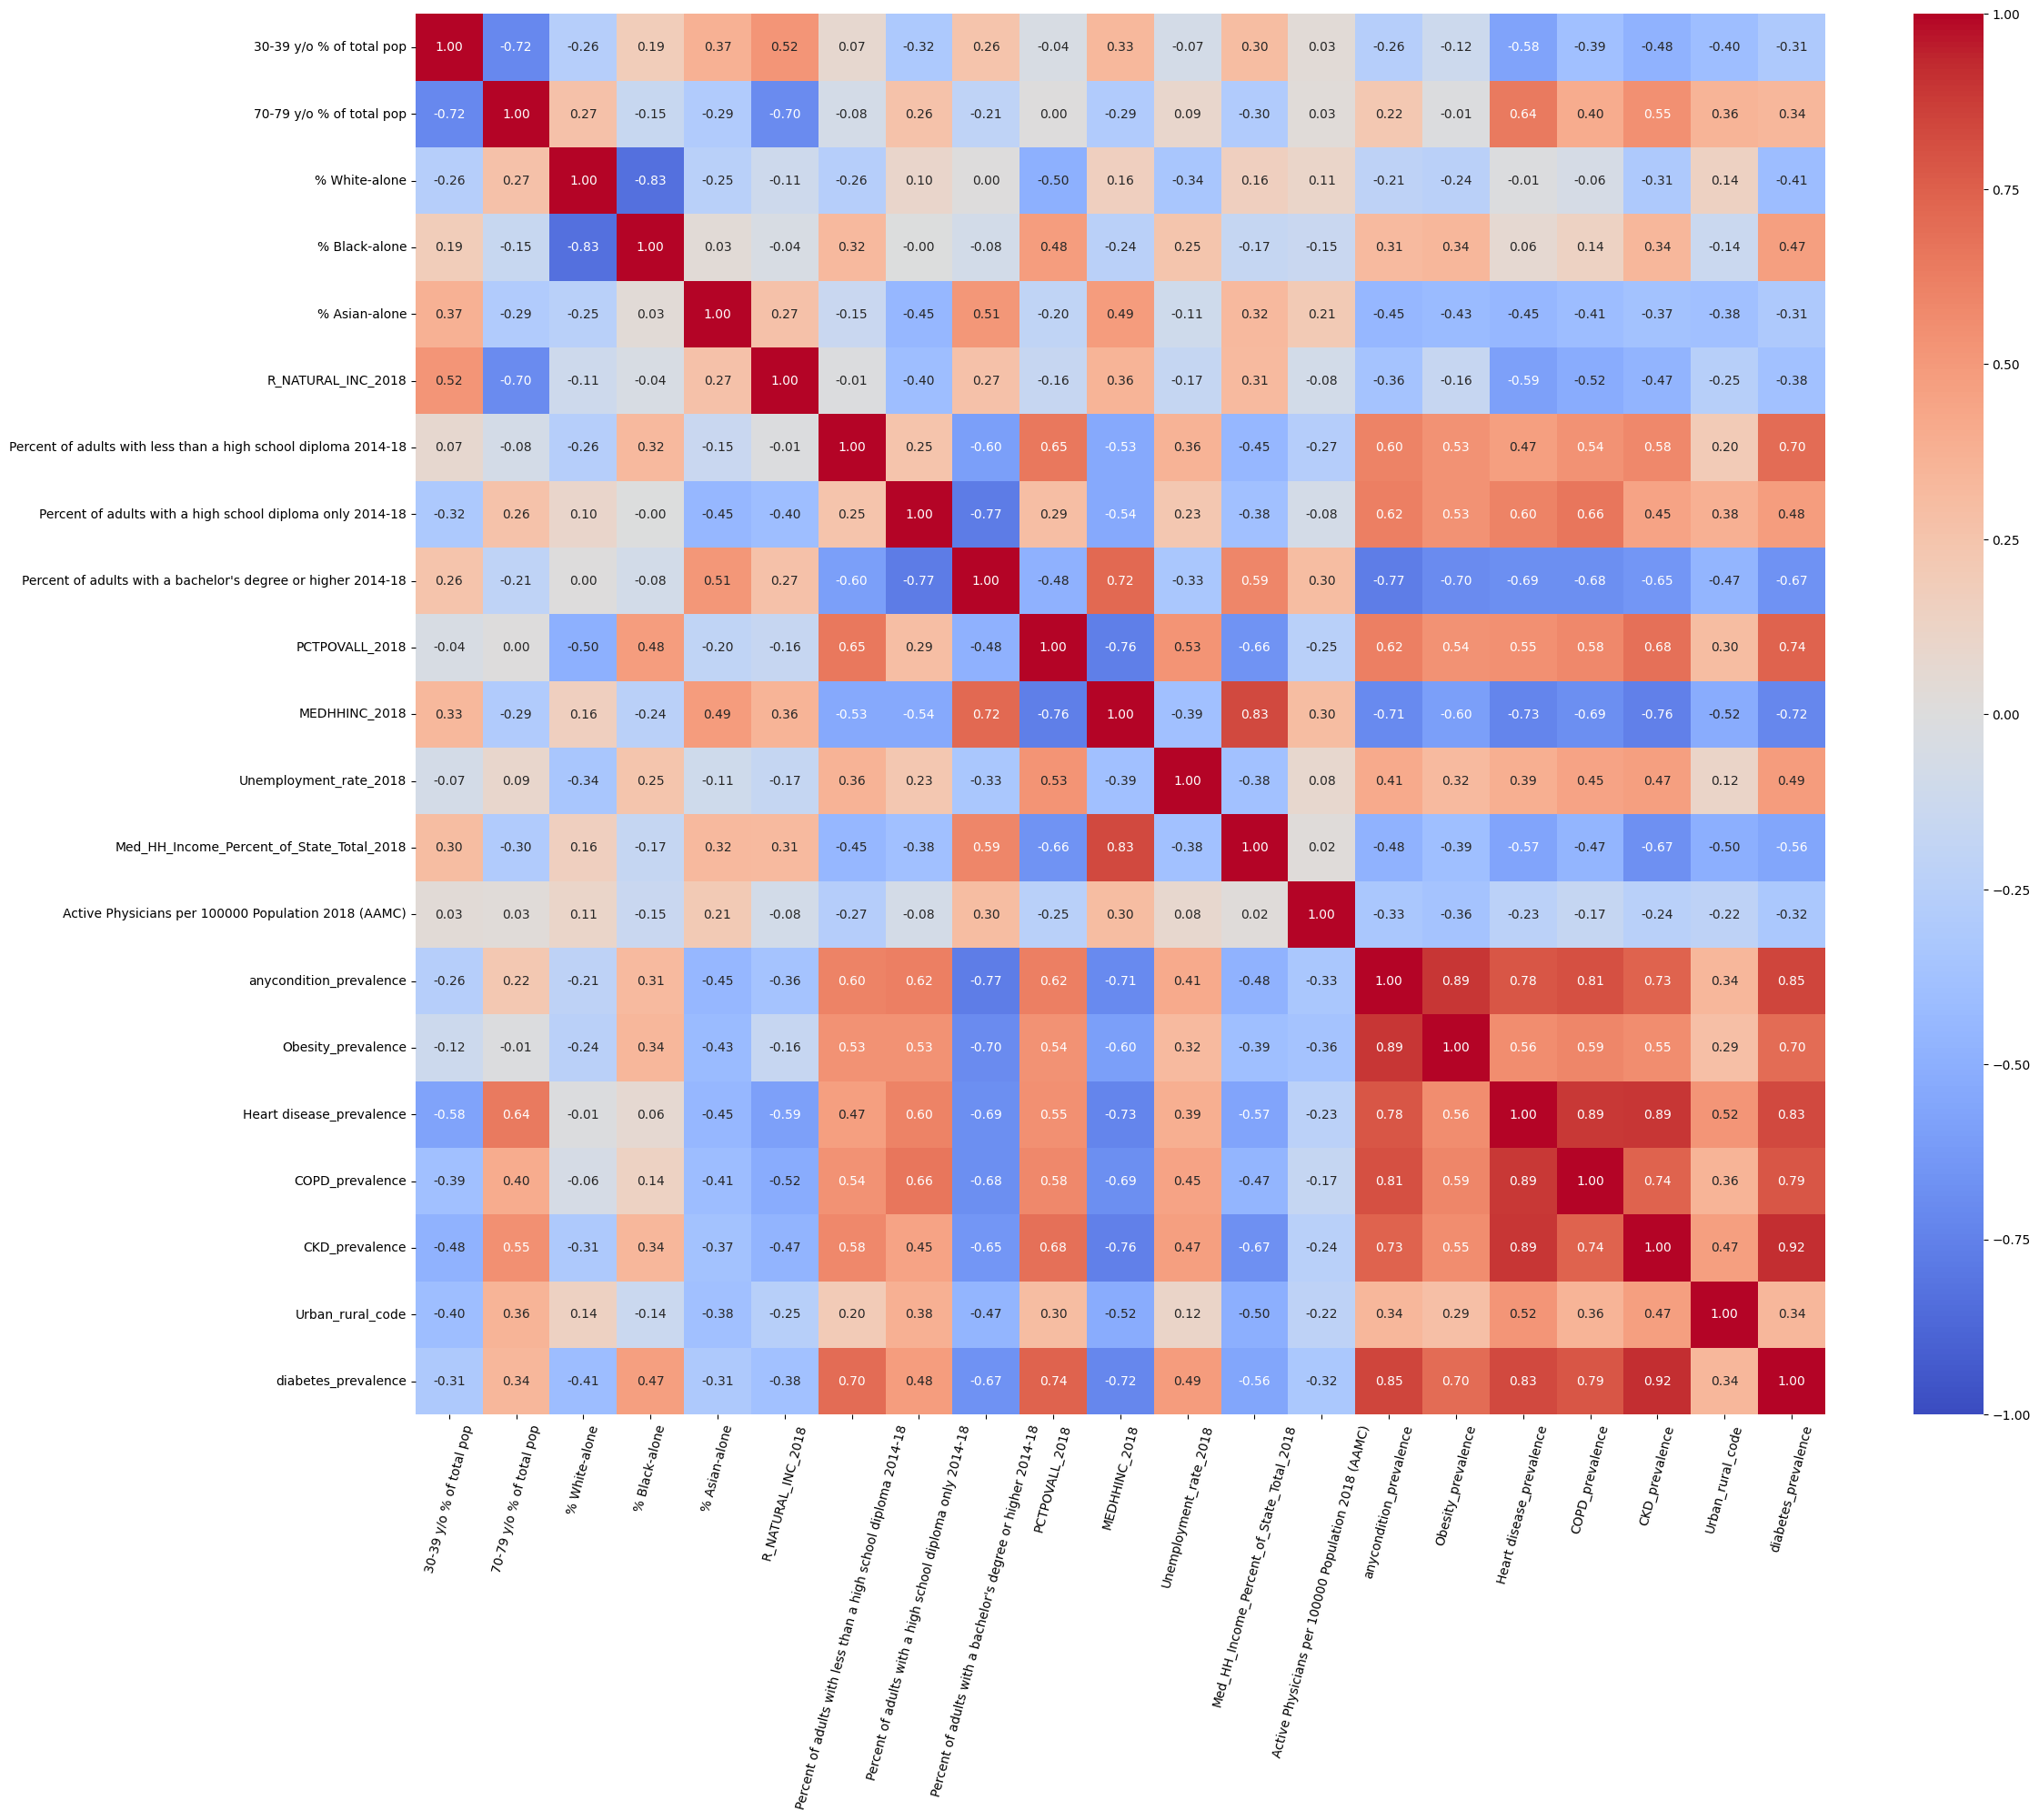

In [78]:
corr = ds_correlacion.corr()

plt.figure(figsize=(25, 20))


sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.tick_params(axis = "x", rotation = 75)
plt.show()

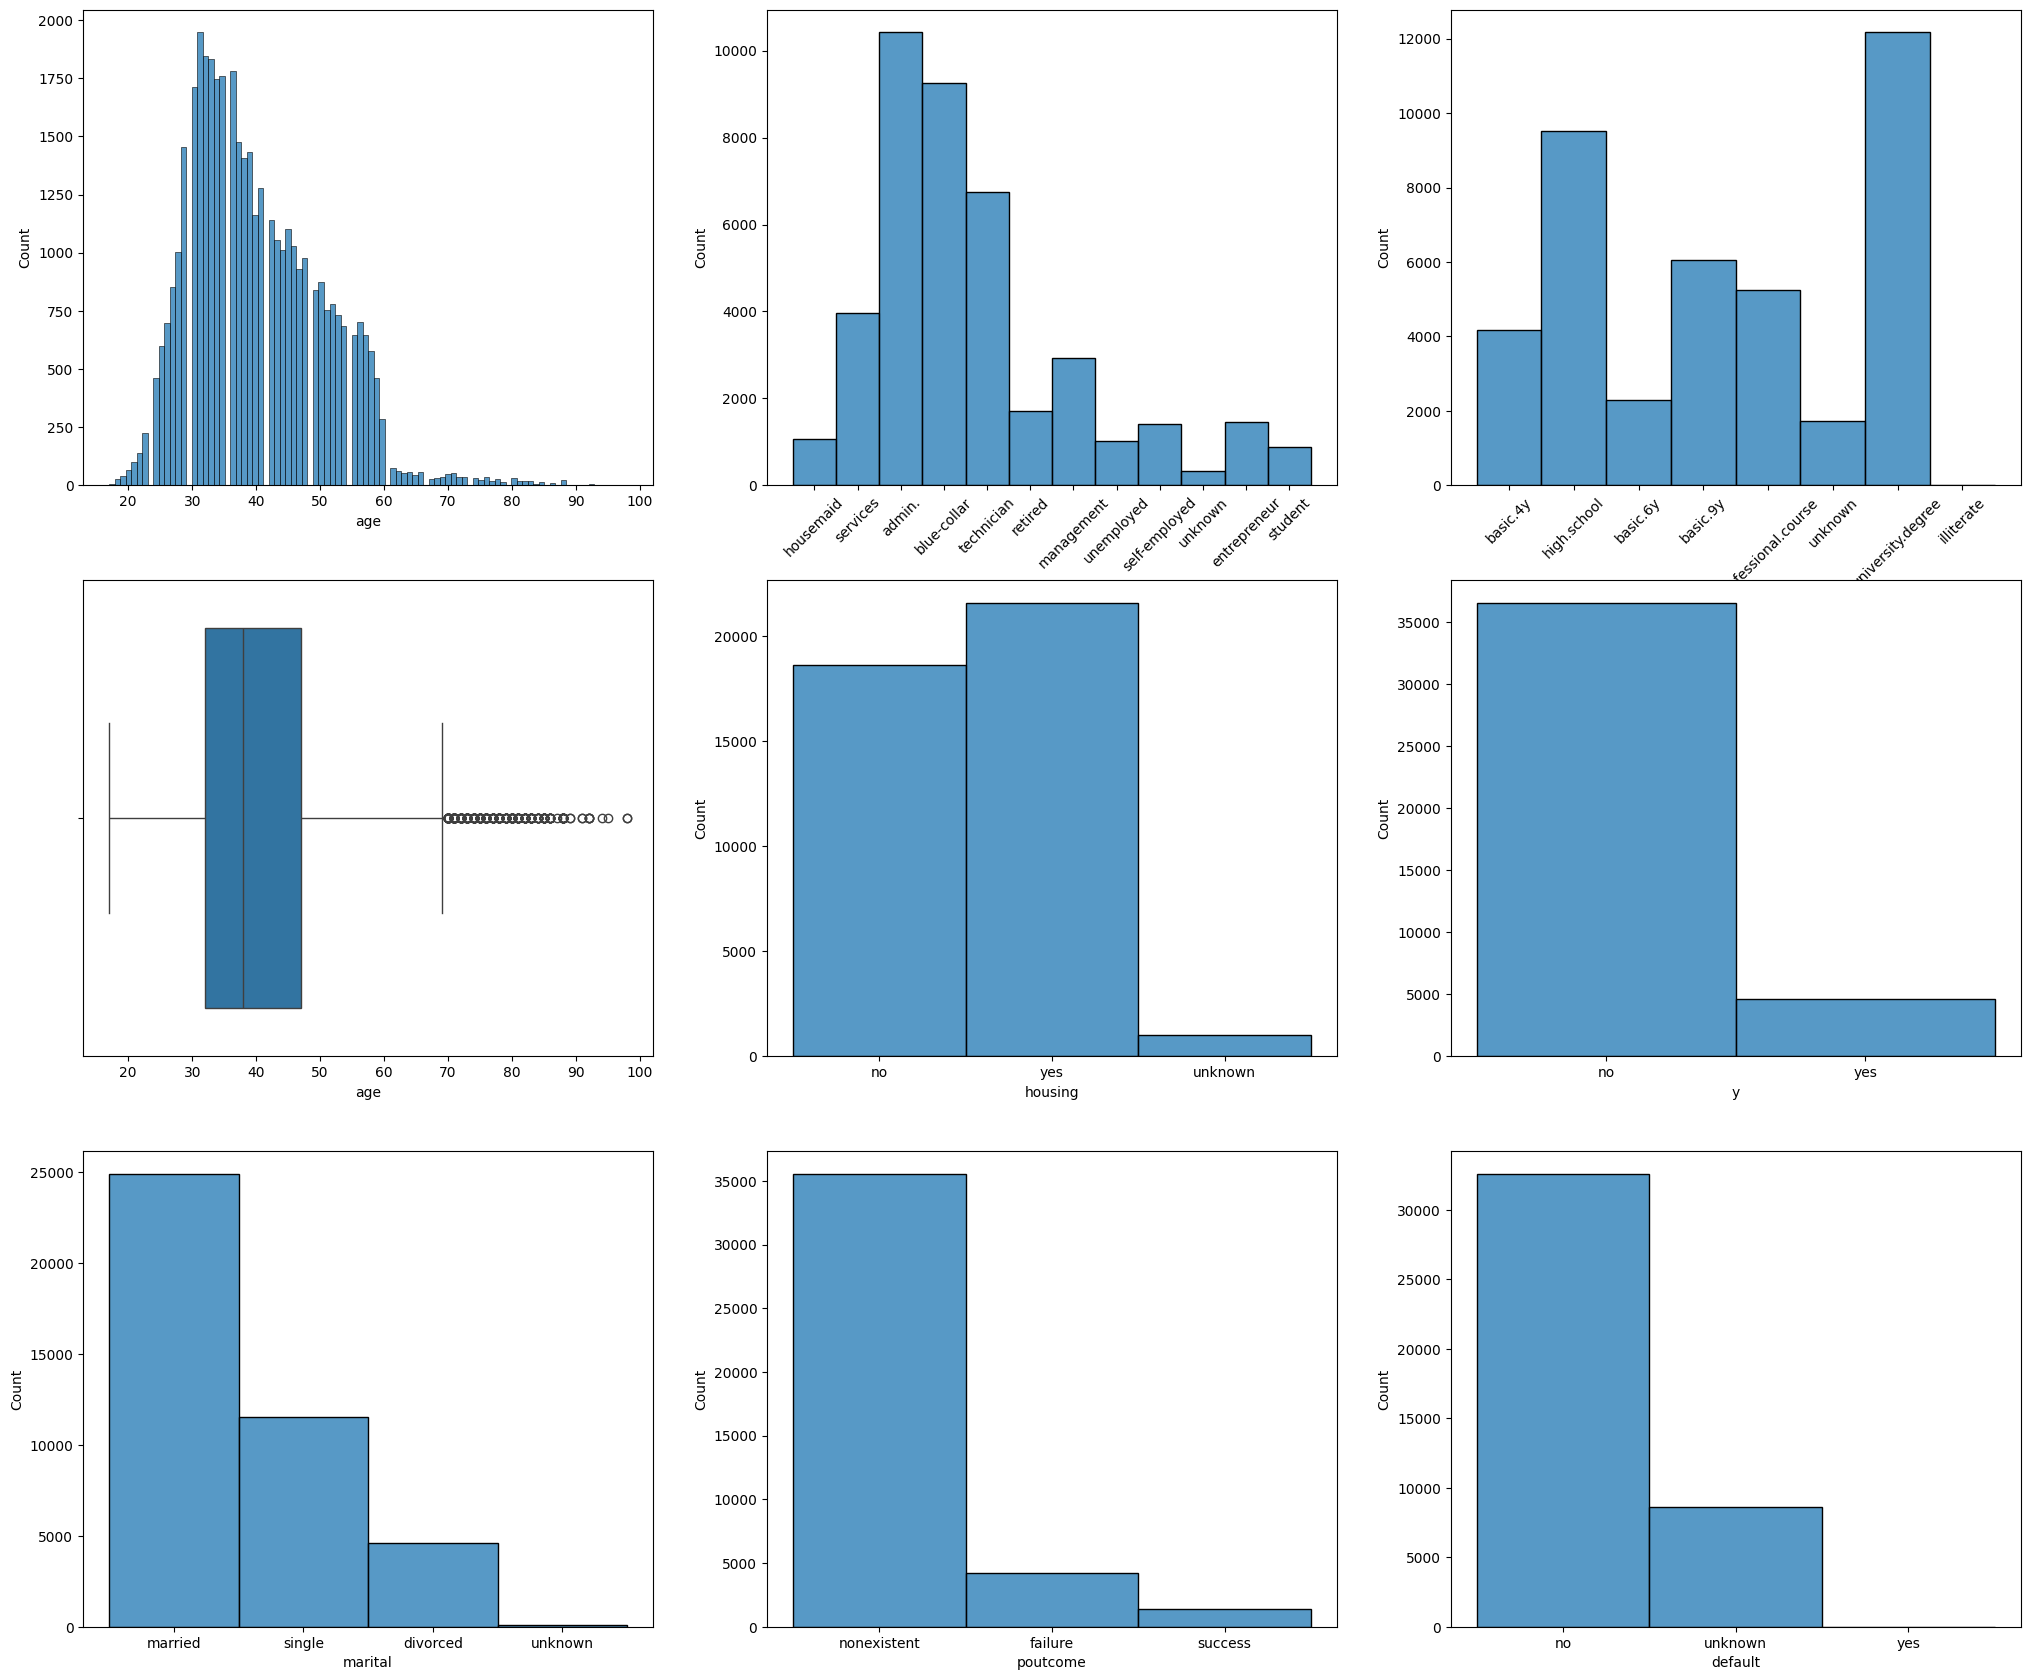

In [ ]:
# Grafico

fig, axis  = plt.subplots(3, 3, figsize = (25,21))

sns.boxplot(ax = axis [0, 0], data = ds, x = "Percent of adults with less than a high school diploma 2014-18")
sns.boxplot(ax = axis [1, 0], data = ds, x = "Percent of adults with a bachelor's degree or higher 2014-18")
sns.boxplot(ax = axis [0, 1], data = ds, x = "PCTPOVALL_2018")
sns.boxplot(ax = axis [0, 2], data = ds, x = "MEDHHINC_2018")
sns.boxplot(ax = axis [2, 0], data = ds, x = "Med_HH_Income_Percent_of_State_Total_2018")
sns.boxplot(ax = axis [1, 1], data = ds, x = "anycondition_prevalence")
sns.boxplot(ax = axis [2, 1], data = ds, x = "Obesity_prevalence")
sns.boxplot(ax = axis [2, 2], data = ds, x = "Heart disease_prevalence")
sns.boxplot(ax = axis [1, 2], data = ds, x = "COPD_prevalence")


axis[0, 1].tick_params(axis = "x", rotation = 45)
axis[0, 2].tick_params(axis = "x", rotation = 45)

plt.show()

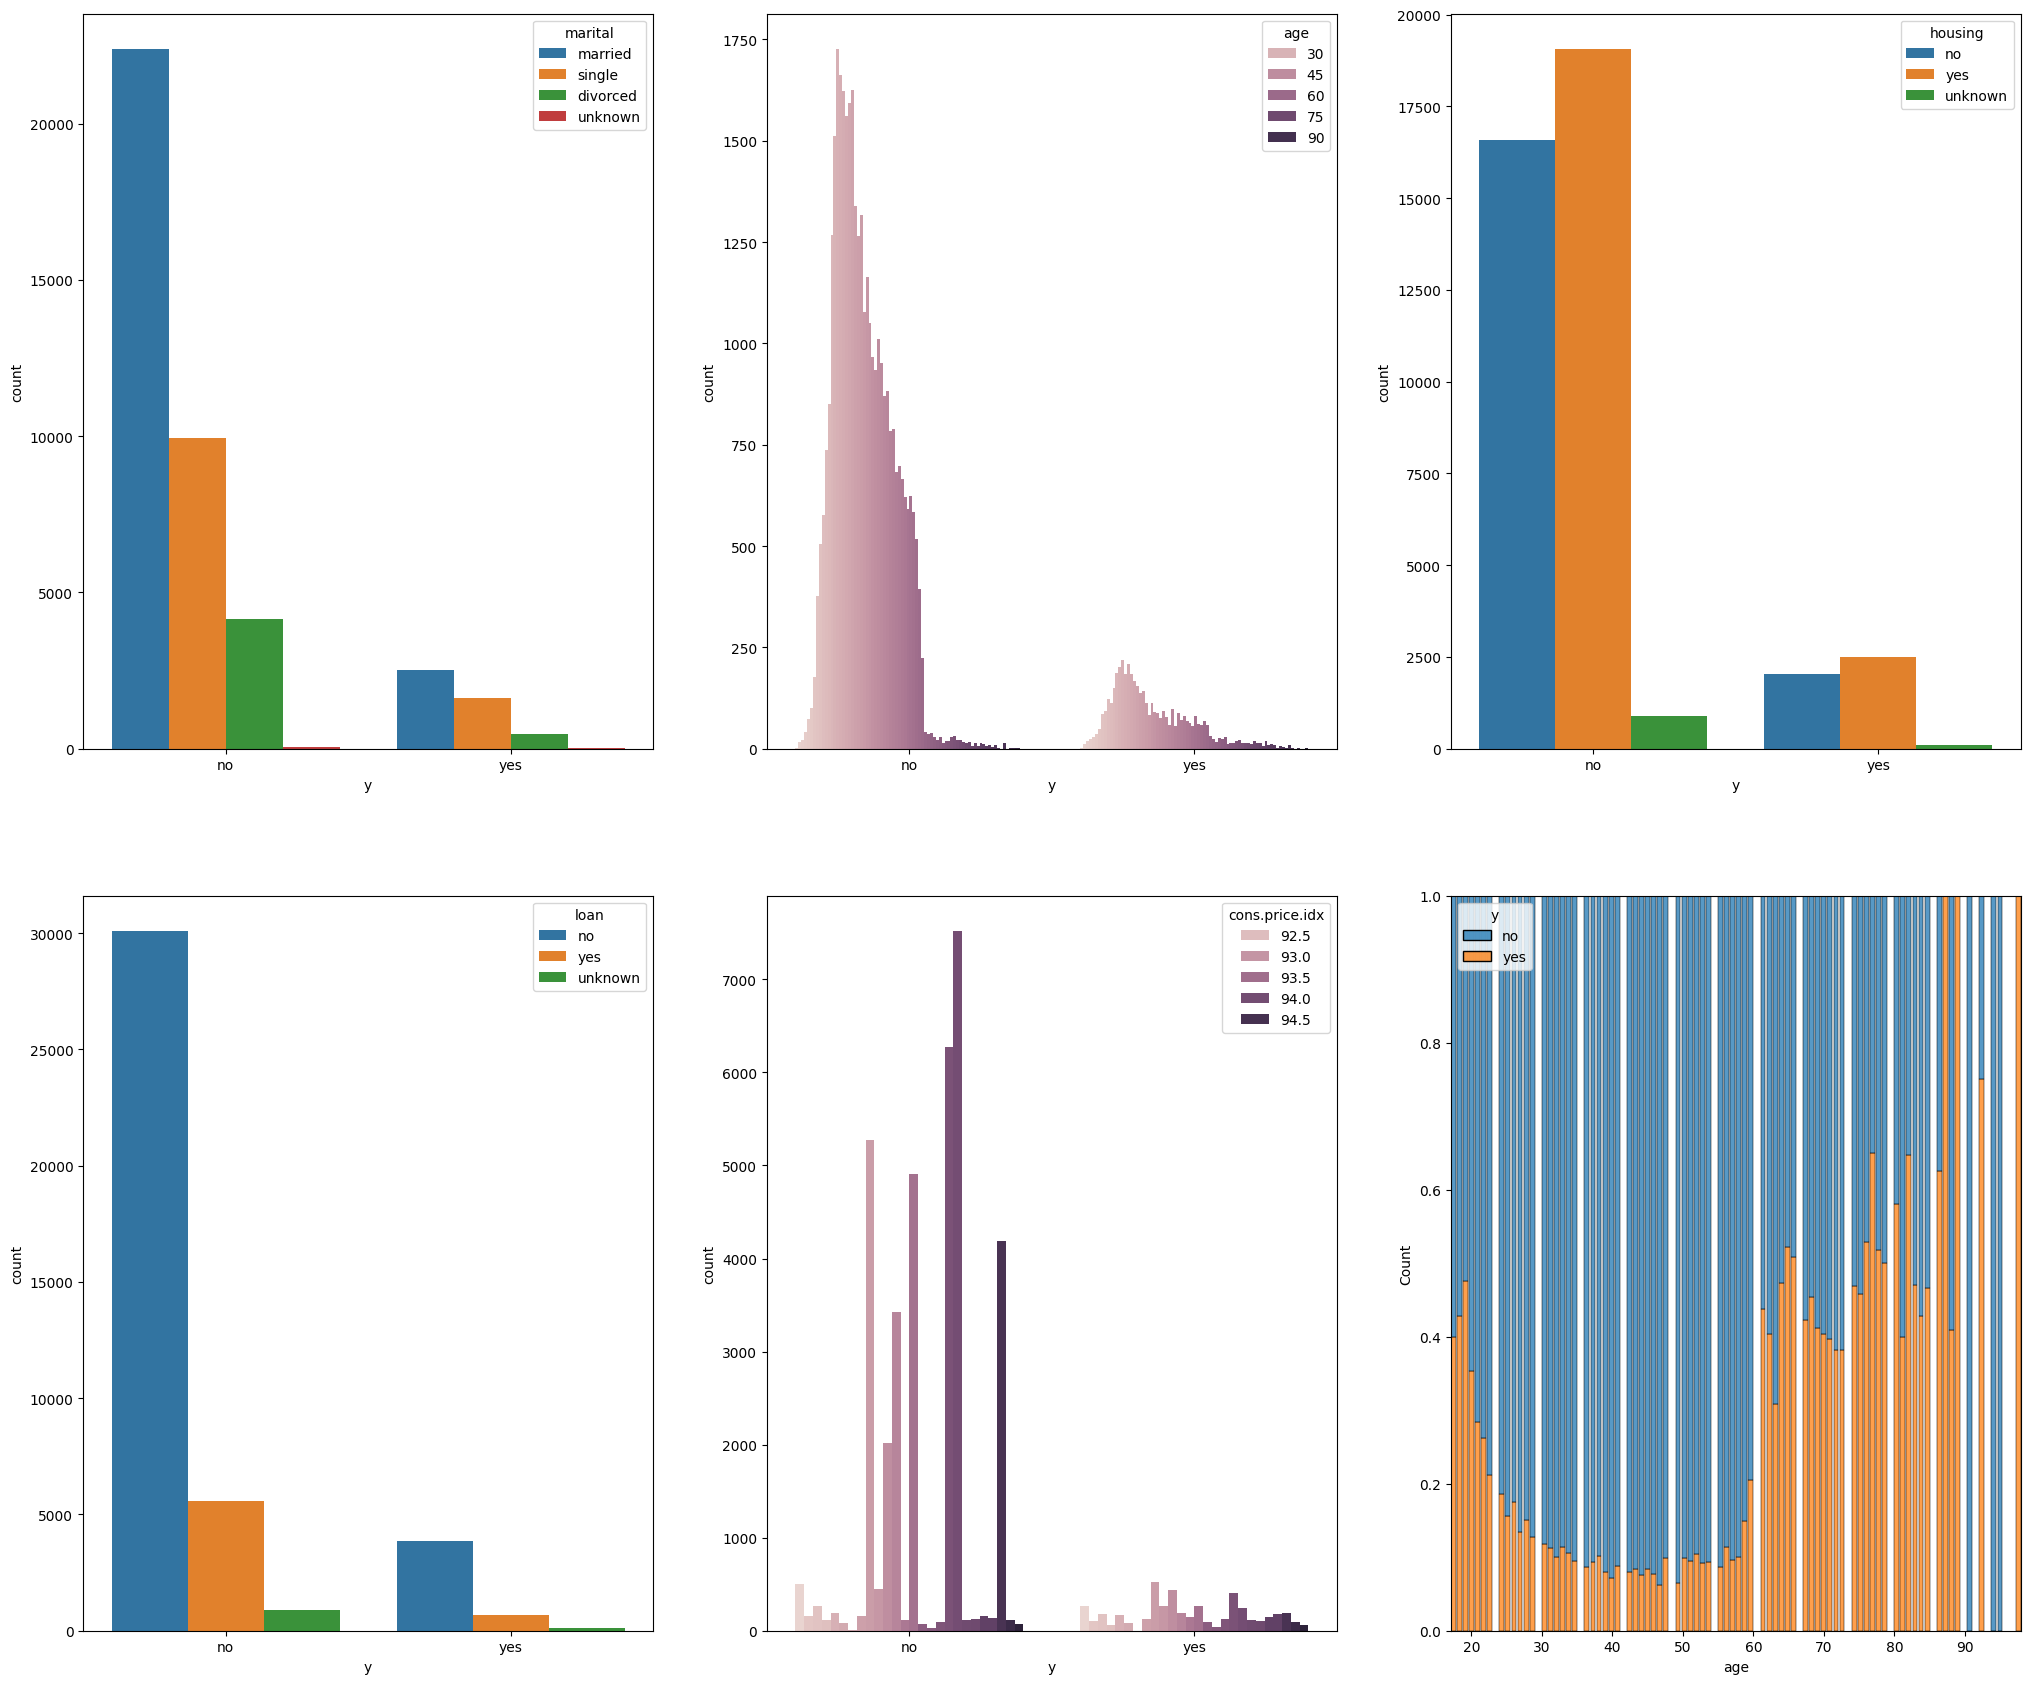

In [109]:
#Grafico

fig, axis  = plt.subplots(2, 3, figsize = (25,21))

sns.countplot (ax = axis [0, 0], data = ds, x = "y", hue = "marital")
sns.countplot (ax = axis [0, 1], data = ds, x = "y", hue = "age")
sns.countplot (ax = axis [0, 2], data = ds, x = "y", hue = "housing")
sns.countplot (ax = axis [1, 0], data = ds, x = "y", hue = "loan")
sns.countplot (ax = axis [1, 1], data = ds, x = "y", hue = "cons.price.idx")
sns.histplot(ax = axis [1, 2], data = ds, x = "age", hue = "y", multiple = "fill", shrink = 0.8)


plt.show()


In [ ]:
# En este dataset no habia valores nulos pero si muchos desconocidos, no eran muchos entonces directamente los saque. Me dejo el dataset limpio

ds_limpio = ds[(ds != 'unknown').all(axis=1)]

ds_limpio

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
# Hago un label encoder para poder hacer el heatmap de correlacion. Creo una nueva variable ds_label_encoded para poder usarla solo para el heatmap de correlacion

columnas_categoricas = ds_limpio.select_dtypes(include= ["object"]).columns

ds_label_coded = ds_limpio.copy()

le = LabelEncoder()

ds_label_coded[columnas_categoricas] = ds_label_coded[columnas_categoricas].apply(le.fit_transform)

ds_label_coded

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
6,59,0,1,5,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,1,0,0,7,0,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,7,0,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,7,0,...,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,7,0,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


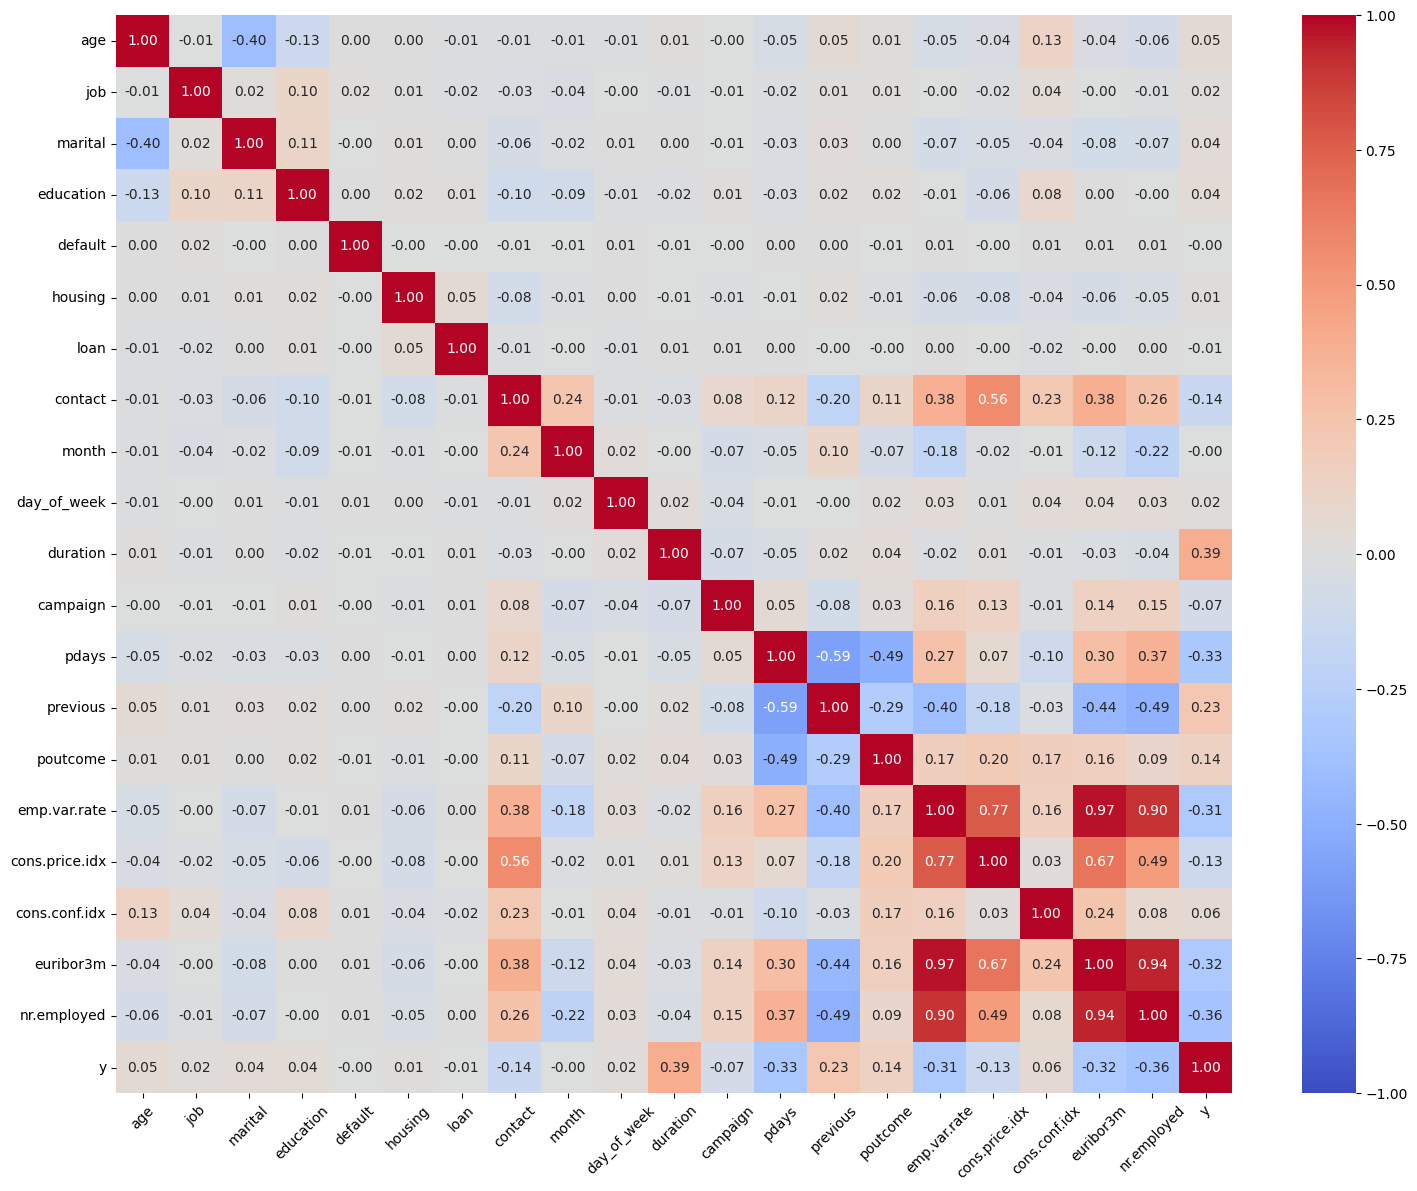

In [112]:
# Heatmap de correlacion

corr = ds_label_coded.corr()

plt.figure(figsize=(18, 14))


sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.tick_params(axis = "x", rotation = 45)
plt.show()


age. Edad del cliente (numérico)
job. Tipo de trabajo (categórico)
marital. Estado civil (categórico)
education. Nivel de educación (categórico)
default. ¿Tiene crédito actualmente? (categórico)
housing. ¿Tiene un préstamo de vivienda? (categórico)
loan. ¿Tiene un préstamo personal? (categórico)
contact. Tipo de comunicación de contacto (categórico)
month. Último mes en el que se le ha contactado (categórico)
day_of_week. Último día en el que se le ha contactado (categórico)
duration. Duración del contacto previo en segundos (numérico)
campaign. Número de contactos realizados durante esta campaña al cliente (numérico)
pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)
poutcome. Resultado de la campaña de marketing anterior (categórico)
emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico)
cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico)
cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico)
euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico)
nr.employed. Número de empleados. Indicador trimestral (numérico)
y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico)

columnas a eliminar = default, duration, day_of_week, poutcome, cons.conf.idx

In [113]:
# Confirmo que ya no tengo desconocidos

unknown = (ds_label_coded == 'unknown').sum()

unknown


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [114]:
columnas_categoricas = ds_limpio.select_dtypes(include= ["object"]).columns

columnas_categoricas

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

In [115]:
ds_limpio

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
#Hago el OneHotEncoder de las columnas categoricas

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(ds_limpio[['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month']])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month']))

ds_limpio.reset_index(drop = True, inplace = True)

def concatenacion():
    global ds_limpio
    if "month_aug" not in ds_limpio:
        ds_limpio = pd.concat([ds_limpio, one_hot_df], axis=1)
        return ds_limpio
concatenacion()

ds_limpio


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30483,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30484,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30485,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30486,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Dropeo las columnas innecesarias para que ya quede el dataset totalmente limpio

ds_limpio.drop(["job", "marital", "education", "housing", "loan", "contact", "month", "default", "day_of_week", "duration", "poutcome", "cons.conf.idx"], axis= 1, inplace= True)

ds_limpio

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,y,job_admin.,...,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,56,1,999,0,1.1,93.994,4.857,5191.0,no,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,37,1,999,0,1.1,93.994,4.857,5191.0,no,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,40,1,999,0,1.1,93.994,4.857,5191.0,no,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,56,1,999,0,1.1,93.994,4.857,5191.0,no,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,59,1,999,0,1.1,93.994,4.857,5191.0,no,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30483,73,1,999,0,-1.1,94.767,1.028,4963.6,yes,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30484,46,1,999,0,-1.1,94.767,1.028,4963.6,no,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30485,56,2,999,0,-1.1,94.767,1.028,4963.6,no,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30486,44,1,999,0,-1.1,94.767,1.028,4963.6,yes,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [118]:
print(ds_limpio.columns)

Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'euribor3m', 'nr.employed', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_divorced',
       'marital_married', 'marital_single', 'education_basic.4y',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'housing_no', 'housing_yes', 'loan_no',
       'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='str')


In [ ]:
# Mapeo la predictora para que sea numerica en vez de categorica

ds_limpio['y'] = ds_limpio['y'].map({'no' : 0, 'yes' : 1})

ds_limpio

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,y,job_admin.,...,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,56,1,999,0,1.1,93.994,4.857,5191.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,37,1,999,0,1.1,93.994,4.857,5191.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,40,1,999,0,1.1,93.994,4.857,5191.0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,56,1,999,0,1.1,93.994,4.857,5191.0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,59,1,999,0,1.1,93.994,4.857,5191.0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30483,73,1,999,0,-1.1,94.767,1.028,4963.6,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30484,46,1,999,0,-1.1,94.767,1.028,4963.6,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30485,56,2,999,0,-1.1,94.767,1.028,4963.6,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30486,44,1,999,0,-1.1,94.767,1.028,4963.6,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [120]:
ds_limpio['y'].value_counts()

y
0    26629
1     3859
Name: count, dtype: int64

In [ ]:
# Preparo todos los datos para el modelo

x = ds_limpio.apply(pd.to_numeric, errors="coerce").drop(['y'], axis = 1)
y = ds_limpio["y"]


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
#Hice el StandardScaler dentro del pipeline

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=30))
])

In [ ]:
# Aplico el pipeline completo al train (imputa nulos, escala y selecciona las mejores features)
X_train_sel = pipe.fit_transform(X_train, y_train)

# Obtengo una máscara True/False indicando qué columnas fueron seleccionadas
mask = pipe.named_steps["selector"].get_support()

# Extraemos los nombres de las columnas seleccionadas
selected_cols = np.array(ds_limpio.columns.drop(['y']))[mask]

# Aplico la misma transformación al test (sin reaprender, solo transforma)
X_test_sel = pipe.transform(X_test)

In [ ]:
#Transformo ambos a un dataset

X_train_sel = pd.DataFrame(X_train_sel, index=X_train.index, columns=selected_cols)
X_test_sel  = pd.DataFrame(X_test_sel,  index=X_test.index,  columns=selected_cols)

print("Features seleccionadas:", list(selected_cols))
X_train_sel.head()

Features seleccionadas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_retired', 'job_services', 'job_student', 'marital_married', 'marital_single', 'education_basic.6y', 'education_basic.9y', 'education_university.degree', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep']


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,job_admin.,job_blue-collar,...,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_mar,month_may,month_nov,month_oct,month_sep
17171,0.676186,0.172163,0.210724,-0.368805,-0.022364,-0.553972,0.385075,0.461278,1.579643,-0.478501,...,-0.701179,-0.271464,-0.427388,-0.072349,-0.449654,-0.124792,-0.683811,2.769003,-0.144965,-0.128798
6617,-0.679497,0.172163,0.210724,-0.368805,0.909849,1.608461,0.839767,0.891788,-0.633055,-0.478501,...,1.426170,-0.271464,-0.427388,-0.072349,-0.449654,-0.124792,-0.683811,-0.361141,-0.144965,-0.128798
19093,1.644531,-0.193385,0.210724,-0.368805,-0.022364,-0.553972,0.310701,0.461278,-0.633055,2.089861,...,-0.701179,-0.271464,-0.427388,-0.072349,-0.449654,-0.124792,-0.683811,2.769003,-0.144965,-0.128798
4966,1.450862,0.172163,0.210724,-0.368805,0.909849,1.608461,0.786241,0.891788,-0.633055,-0.478501,...,1.426170,-0.271464,-0.427388,-0.072349,-0.449654,-0.124792,-0.683811,-0.361141,-0.144965,-0.128798
10988,0.192013,-0.558934,0.210724,-0.368805,0.909849,0.673401,0.840894,0.891788,-0.633055,-0.478501,...,-0.701179,-0.271464,-0.427388,-0.072349,2.223933,-0.124792,-0.683811,-0.361141,-0.144965,-0.128798


In [ ]:
#Guardo ambos en local

X_train_sel["y"] = list(y_train)
X_test_sel["y"] = list(y_test)

X_train_sel.to_csv("../data/processed/train.csv", index=False)
X_test_sel.to_csv("../data/processed/test.csv", index=False)

In [ ]:
#Defino las variables para el modelo

X_train = X_train_sel.drop(["y"], axis = 1)
y_train = X_train_sel["y"]
X_test = X_test_sel.drop(["y"], axis = 1)
y_test = X_test_sel["y"]

In [ ]:
# Empiezo a modelar (uso el class_weight='balanced' porque la columna 'y' esta muy desbalanceada entre positivos y negativos)

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [128]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(6098,))

In [129]:
accuracy_score(y_test, y_pred)

0.8117415546080682

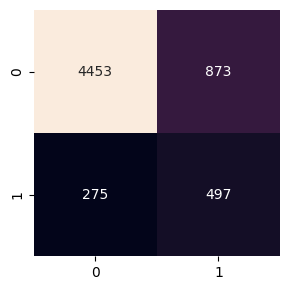

In [ ]:
# Grafico la matriz de confusion

bank_cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(bank_cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()

In [ ]:
# Defino los hiperparametros que quiero usar a mano a ver si mejora el accuracy, empiezo con el GridSearch
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Inicializamos la cuadrícula
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [ ]:
#La funcion es para que no salten advertencias en consola cada vez que encuentra hiperparametros que no son compatibles

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# Ejecuto el GridSearch para saber los mejores hiperparametros

grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 0.001, 'penalty': None, 'solver': 'lbfgs'}


In [ ]:
# Vuelvo a ejecutar el modelo pero usando los hiperparametros (agrego de nuevo el class_weight='balanced')

model_grid = LogisticRegression(penalty = None, C = 0.001, solver = "lbfgs", class_weight='balanced')
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.8119055428009183

In [ ]:
# Defino los hiperparamentros pero ahora para la busqueda aleatoria
hyperparams = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Ejecuto la busqueda aleatoria
random_search = RandomizedSearchCV(model, hyperparams, n_iter = 100, scoring = "accuracy", cv = 5, random_state = 42)
random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ht='balanced')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0

In [135]:
random_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {random_search.best_params_}")

Mejores hiperparámetros: {'solver': 'saga', 'penalty': 'l2', 'C': np.float64(545.5594781168514)}


In [ ]:
# Vuelvo a ejecutar el modelo pero utilizando los hiperparametros que me dio la busqueda aleatoria

model_random_search = LogisticRegression(penalty = "l2", C = 545, solver = "saga", class_weight='balanced')
model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.8119055428009183

In [ ]:
#Veo las metricas

print(classification_report(y_test, y_pred, target_names=['No contrata', 'Contrata']))

              precision    recall  f1-score   support

 No contrata       0.94      0.84      0.89      5326
    Contrata       0.36      0.64      0.46       772

    accuracy                           0.81      6098
   macro avg       0.65      0.74      0.67      6098
weighted avg       0.87      0.81      0.83      6098



Conclusiones: en este caso siendo un modelo que quiere predecir que clientes van a contratar o no un servicio. En este caso creo que lo mejor seria incrementar el recall para poder ser mas precisio a la hora de encontrar clientes que si quieran contratar el servicio. Es decir, es mejor en este caso perder tiempo llamando a clientes que no contratan que no llamar a clientes pensando que no van a contratar y que en realidad si eran potenciales clientes exitosos. Muchas gracias Cesar!